<font size = 10>Optimizer</font>

# Local run setup: Windows vs Mac (CUDA vs MPS)

Set the parameter below to match your machine:

- **Windows** → prefers **CUDA** (NVIDIA GPU) if available  
- **Mac** → prefers **MPS** (Apple Silicon GPU) if available  

If the preferred accelerator is not available, the notebook will **fall back to CPU**.

This notebook includes plotting and scalar-printing from tensors, so the helpers `to_numpy(...)` and `to_scalar(...)` safely move tensors to CPU when needed.


In [1]:
# ===== Platform / device selector =====
# Set this to: "Windows" or "Mac"
PLATFORM = "Mac"

# Set to False if you want to force CPU even when a GPU backend is available
USE_ACCELERATOR = True

import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

%matplotlib inline
import numpy as np
import torch
import matplotlib.pyplot as plt

def pick_device(platform_choice: str, use_accelerator: bool = True) -> torch.device:
    if not use_accelerator:
        return torch.device("cpu")

    p = platform_choice.strip().lower()

    if p.startswith("mac"):
        if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
            return torch.device("mps")
        if torch.cuda.is_available():
            return torch.device("cuda")
        return torch.device("cpu")

    if p.startswith("win"):
        if torch.cuda.is_available():
            return torch.device("cuda")
        return torch.device("cpu")

    raise ValueError('PLATFORM must be "Windows" or "Mac".')

DEVICE = pick_device(PLATFORM, USE_ACCELERATOR)

def to_numpy(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)

def to_scalar(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().item()
    return float(x)

print(f"PLATFORM = {PLATFORM}")
print(f"Selected DEVICE = {DEVICE}")

if DEVICE.type == "cuda":
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")
elif DEVICE.type == "mps":
    print("Using Apple Silicon GPU via MPS")
else:
    print("Using CPU")


PLATFORM = Mac
Selected DEVICE = mps
Using Apple Silicon GPU via MPS


# PyTorch SDG Optimizer

In [2]:
# Imports are handled in the setup cell above.

- calling <code>tensor.backward()</code> computes gradients with respect to all leafs.<br>
- These gradients accumulate at the leafs: every call adds newly computed gradients to the stored values.<br>
- Make sure to zero gradients at the *leafs* before calling <code>tensor.backward()</code>: <code>params.grad.zero_()</code><br>
- <code>with torch.no_grad():</code> - defines block within which computations are not added to the computational graph (e.g. for model validation). 

## Implement the Training Loop

In [3]:
def training_loop(n_epochs, model, optimizer, criterion, params, t_u, t_c):
    '''
        n_epochs - number of iterations, int
        model - a function implementing the model being optimized
        optimizer - an object that uses gradients to compute new values of the parameters & update them 
        criterion - loss function, receives two sets of values:
                    predicted with the model (with current parameters) and True values 
        params - initial model parameters (with grad=True)
        t_u, t_c - X's and y's for the model. 
    '''
    for epoch in range(1, n_epochs + 1):                
        t_p = model(t_u, *params) # forward pass: compute the model predictions t_u -> t_p ~ t_c
        loss = criterion(t_p, t_c) # compute loss         
        optimizer.zero_grad() # clear gradients of all model parameters. 
        loss.backward() # backward pass: compute gradient of the loss for all model parameters. 
        optimizer.step() # use gradients to update the model parameters 
        
        if epoch % 500 == 0:
            print('Epoch %d, Loss %f' % (epoch, to_scalar(loss)))
            
    return params

## Run the Model

### Accelerate conversion with data normalization
$ \large t_u \rightarrow 0.1 \cdot t_u$

In [4]:
t_c = torch.tensor([0.5,  14.0, 15.0, 28.0, 11.0,  8.0,  3.0, -4.0,  6.0, 13.0, 21.0], device=DEVICE)
t_u = torch.tensor([35.7, 55.9, 58.2, 81.9, 56.3, 48.9, 33.9, 21.8, 48.4, 60.4, 68.4], device=DEVICE)

params = torch.tensor([1.0, 0.0], device=DEVICE, requires_grad=True)  # model parameters, (w, b)

learning_rate = 0.01

def model(t_u, w, b):
    return w * t_u + b

def loss_fn(t_p, t_c):
    return torch.mean(torch.square(t_p - t_c))

training_loop(
    n_epochs=5000,
    model=model,
    optimizer=torch.optim.Adam([params], lr=learning_rate),
    criterion=loss_fn,
    params=params,
    t_u=0.1 * t_u,
    t_c=t_c,
)


Epoch 500, Loss 24.946455
Epoch 1000, Loss 15.752769
Epoch 1500, Loss 9.455151
Epoch 2000, Loss 5.767540
Epoch 2500, Loss 3.932836
Epoch 3000, Loss 3.196811
Epoch 3500, Loss 2.977151
Epoch 4000, Loss 2.933181
Epoch 4500, Loss 2.927968
Epoch 5000, Loss 2.927654


tensor([  5.3660, -17.2952], device='mps:0', requires_grad=True)

Normalize inputs:
$ \large t_u \rightarrow \frac {t_u-mean(t_u)} {std(t_u)}$

In [5]:
params = training_loop(
    n_epochs = 5000,
    model = model, 
    optimizer = torch.optim.Adam([params], lr = learning_rate), 
    criterion = loss_fn,
    params = params,
    t_u =(t_u-t_u.mean())/t_u.std(),
    t_c = t_c)
params

Epoch 500, Loss 532.528320
Epoch 1000, Loss 350.267761
Epoch 1500, Loss 218.439072
Epoch 2000, Loss 127.131096
Epoch 2500, Loss 67.788818
Epoch 3000, Loss 32.579960
Epoch 3500, Loss 14.241548
Epoch 4000, Loss 6.303802
Epoch 4500, Loss 3.650931
Epoch 5000, Loss 3.027382


tensor([ 9.0349, 10.1849], device='mps:0', requires_grad=True)

Note that Adam was smart enough to converge fast even without parameter perfect normalization (in this simple case).<br>
However, it won't converge that fast without normalization at all. 

In [6]:
params = training_loop(
    n_epochs = 20000,
    model = model, 
    optimizer = torch.optim.Adam([params], lr = learning_rate), 
    criterion = loss_fn,
    params = params,
    t_u =t_u,
    t_c = t_c)
params

Epoch 500, Loss 62471.863281
Epoch 1000, Loss 9745.358398
Epoch 1500, Loss 741.640137
Epoch 2000, Loss 52.083694
Epoch 2500, Loss 33.033779
Epoch 3000, Loss 32.596436
Epoch 3500, Loss 32.215652
Epoch 4000, Loss 31.730377
Epoch 4500, Loss 31.116266
Epoch 5000, Loss 30.344971
Epoch 5500, Loss 29.384422
Epoch 6000, Loss 28.200218
Epoch 6500, Loss 26.758564
Epoch 7000, Loss 25.031300
Epoch 7500, Loss 23.003510
Epoch 8000, Loss 20.683750
Epoch 8500, Loss 18.115484
Epoch 9000, Loss 15.386233
Epoch 9500, Loss 12.628982
Epoch 10000, Loss 10.009894
Epoch 10500, Loss 7.700378
Epoch 11000, Loss 5.838514
Epoch 11500, Loss 4.492920
Epoch 12000, Loss 3.644044
Epoch 12500, Loss 3.193671
Epoch 13000, Loss 3.002807
Epoch 13500, Loss 2.942494
Epoch 14000, Loss 2.929482
Epoch 14500, Loss 2.927769
Epoch 15000, Loss 2.927650
Epoch 15500, Loss 2.927645
Epoch 16000, Loss 2.927645
Epoch 16500, Loss 2.927646
Epoch 17000, Loss 2.927646
Epoch 17500, Loss 2.927646
Epoch 18000, Loss 2.927645
Epoch 18500, Loss 2.92

tensor([  0.5368, -17.3048], device='mps:0', requires_grad=True)

## Using trained model

### train the model (again)

In [7]:
params = training_loop(
    n_epochs = 5000,
    model = model, 
    optimizer = torch.optim.Adam([params], lr = learning_rate), 
    criterion = loss_fn,
    params = params,
    t_u =(t_u-t_u.mean())/t_u.std(),
    t_c = t_c)
w,b = params
print(f"Inferred parameters: w={to_scalar(w):0.3f}, b={to_scalar(b):0.3f}")

Epoch 500, Loss 549.011780
Epoch 1000, Loss 352.882416
Epoch 1500, Loss 218.837738
Epoch 2000, Loss 127.317047
Epoch 2500, Loss 67.907501
Epoch 3000, Loss 32.648373
Epoch 3500, Loss 14.274958
Epoch 4000, Loss 6.316730
Epoch 4500, Loss 3.654544
Epoch 5000, Loss 3.028038
Inferred parameters: w=9.035, b=10.184


### Apply trained model

In [8]:
to_scalar(model(t_u=10, w=w, b=b)), to_scalar(model(10, *params))

(100.53274536132812, 100.53274536132812)

there's really no need to compute gradients during inferrence. 

In [9]:
with torch.no_grad():
    t_p = model(t_u=10, w=w, b=b)
to_scalar(t_p)


100.53274536132812

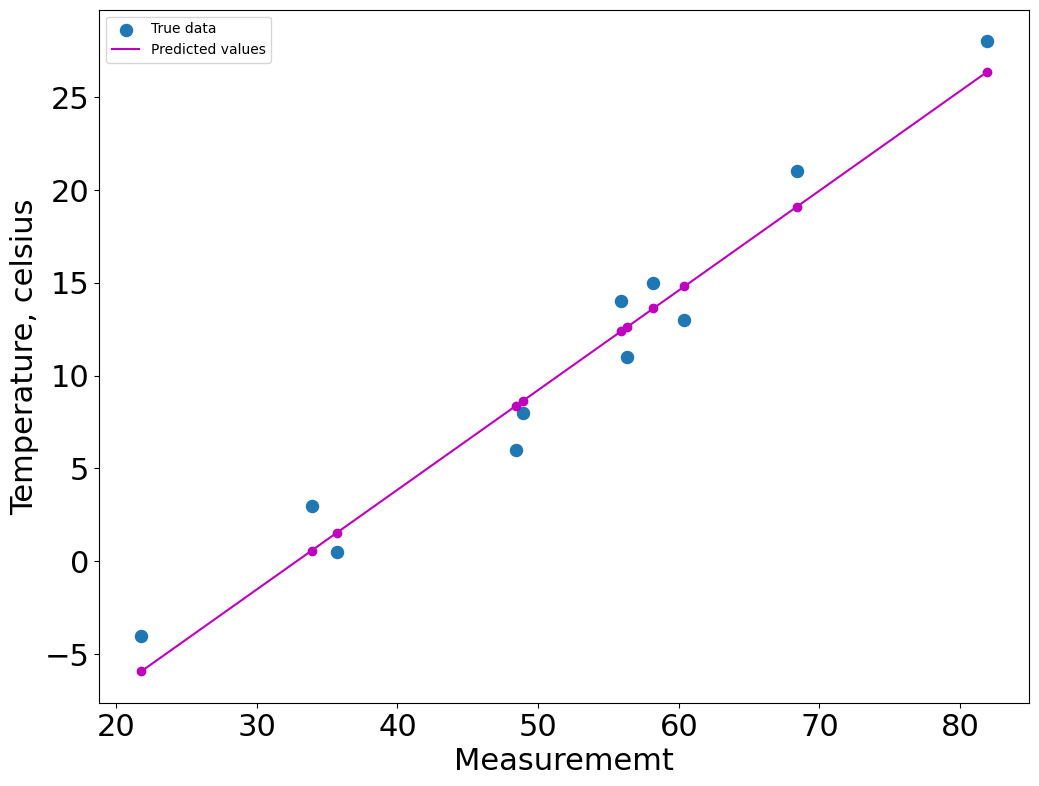

In [10]:
plt.figure(figsize=(12, 9))
plt.scatter(to_numpy(t_u), to_numpy(t_c), s=75, label='True data')
with torch.no_grad():
    t_us = torch.linspace(to_scalar(t_u.min()), to_scalar(t_u.max()), 100, device=DEVICE)
    t_ps = model(t_u=(t_us - t_u.mean()) / t_u.std(), w=w, b=b)  # note normalization!
    plt.plot(to_numpy(t_us), to_numpy(t_ps), '-m', label='Predicted values')

    t_p = model(t_u=(t_u - t_u.mean()) / t_u.std(), w=w, b=b)
    plt.plot(to_numpy(t_u), to_numpy(t_p), 'om', label=None)
plt.xlabel('Measurememt', fontsize=22)
plt.ylabel('Temperature, celsius', fontsize=22)
plt.gca().tick_params(axis='x', labelsize=22)
plt.gca().tick_params(axis='y', labelsize=22)
plt.legend();


In [11]:
import torch.optim

In [12]:
dir(torch.optim)

['ASGD',
 'Adadelta',
 'Adafactor',
 'Adagrad',
 'Adam',
 'AdamW',
 'Adamax',
 'LBFGS',
 'NAdam',
 'Optimizer',
 'RAdam',
 'RMSprop',
 'Rprop',
 'SGD',
 'SparseAdam',
 '__all__',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '_adafactor',
 '_functional',
 'lr_scheduler',
 'swa_utils']